In [3]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import pandas_ta as ta

start_date = '2024-01-01'
end_date = '2025-01-01'
sp500 = yf.Ticker("SPY").history(start=start_date, end=end_date)
sp500 = sp500.drop(columns=['Dividends', 'Stock Splits','Capital Gains'])
print(sp500.tail())


                                 Open        High         Low       Close  \
Date                                                                        
2024-12-24 00:00:00-05:00  594.272307  599.536501  593.684050  599.496582   
2024-12-26 00:00:00-05:00  597.701991  600.673034  596.286267  599.536499   
2024-12-27 00:00:00-05:00  595.747844  595.987176  588.988210  593.225464   
2024-12-30 00:00:00-05:00  586.126844  589.965273  582.657240  586.455811   
2024-12-31 00:00:00-05:00  588.140735  588.868587  582.667210  584.322266   

                             Volume  
Date                                 
2024-12-24 00:00:00-05:00  33160100  
2024-12-26 00:00:00-05:00  41219100  
2024-12-27 00:00:00-05:00  64969300  
2024-12-30 00:00:00-05:00  56578800  
2024-12-31 00:00:00-05:00  57052700  


In [4]:
# We can use pandas to calculate the moving average for different time periods
sp500['50ma'] = sp500['Close'].rolling(window=20).mean()
sp500['200ma'] = sp500['Close'].rolling(window=50).mean()

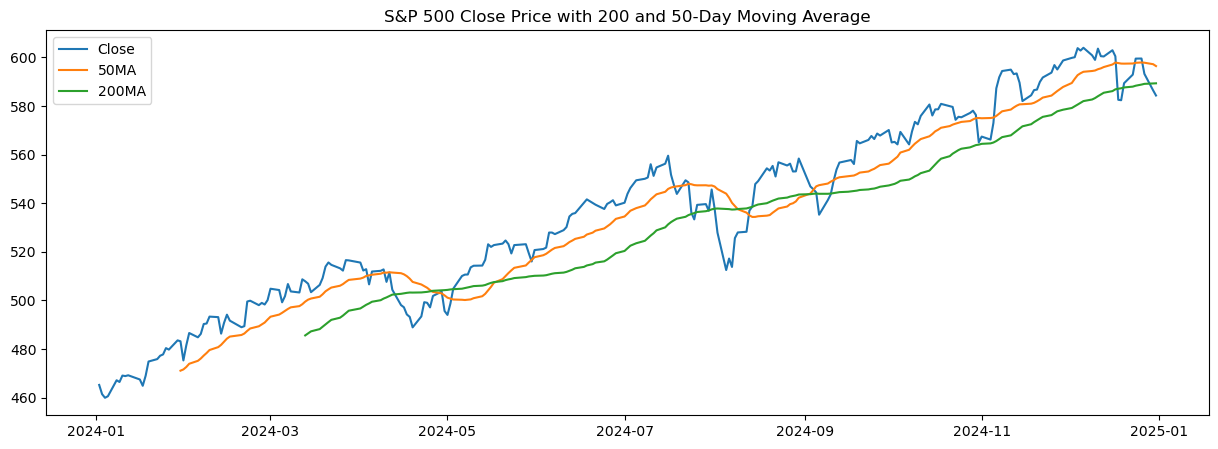

In [7]:
# Let's plot the data to see the moving averages
plt.figure(figsize=(15, 5))
plt.title('S&P 500 Close Price with 200 and 50-Day Moving Average')
plt.plot(sp500['Close'])
plt.plot(sp500['50ma'])
plt.plot(sp500['200ma'])
plt.legend(['Close', '50MA', '200MA'])
plt.show()

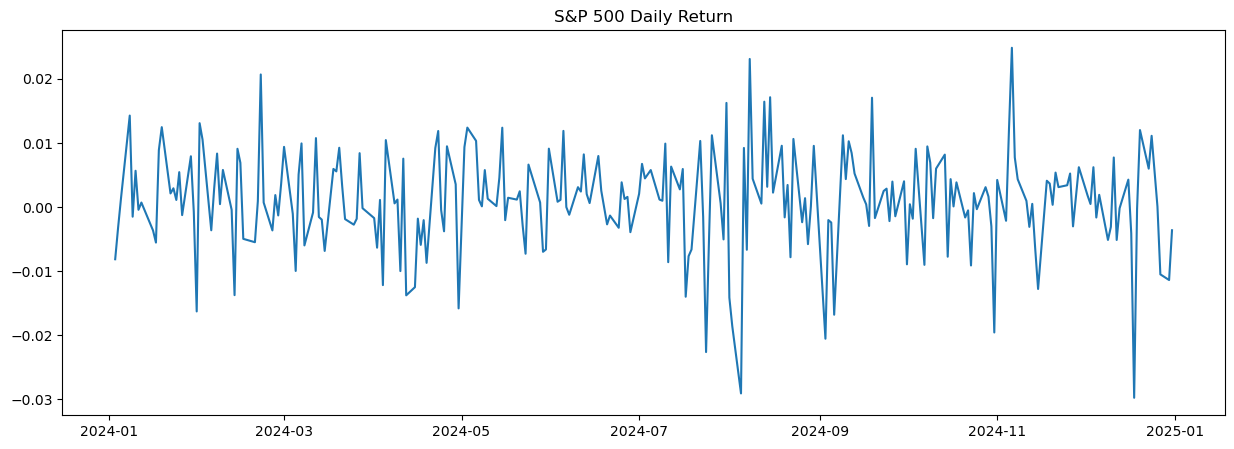

In [9]:
# Calculate the daily return of the close price
sp500['return'] = sp500['Close'].pct_change()

# Plot the daily return
plt.figure(figsize=(15, 5))
plt.title('S&P 500 Daily Return')
plt.plot(sp500['return'])
plt.show()

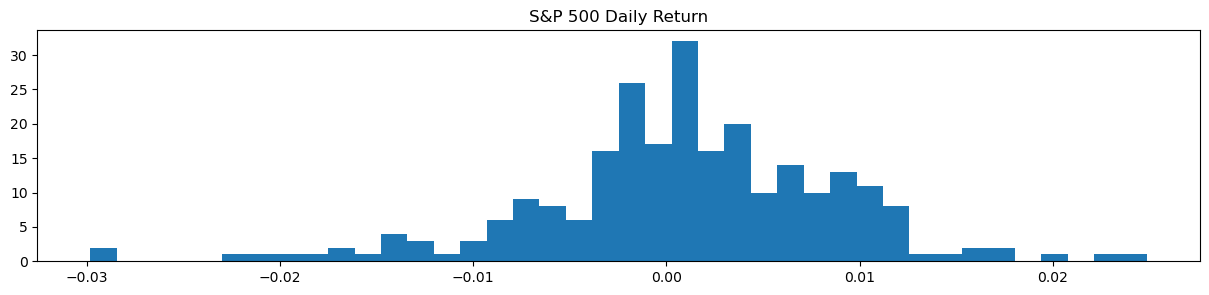

In [11]:
# Plot the daily return using an histogram
plt.figure(figsize=(15, 3))
plt.title('S&P 500 Daily Return')
sp500['return'].hist(bins=40, grid=False)
plt.show()

In [13]:
# Calculate the volatility of the close price
sp500['volatility'] = sp500['return'].rolling(window=50).std() * (50 ** 0.5)

# Calculate the rolling correlation between the return and volatility
sp500['corr252'] = sp500['return'].rolling(window=50).corr(sp500['volatility'])


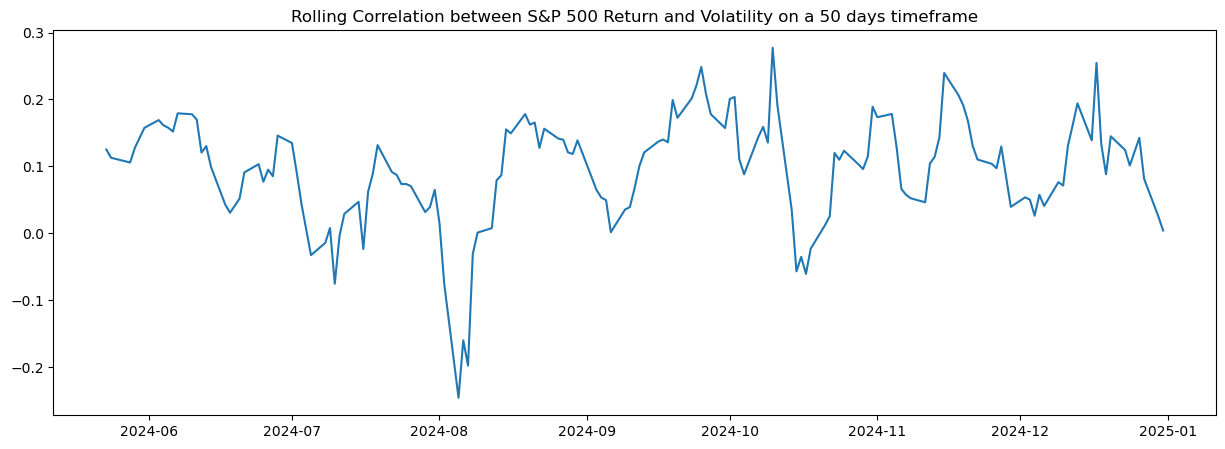

In [15]:
# Calculate the rolling correlation between the return and volatility using a window size of 50 trading days
sp500['corr50'] = sp500['return'].rolling(window=50).corr(sp500['volatility'])

# Plot the rolling correlation
plt.figure(figsize=(15, 5))
plt.title('Rolling Correlation between S&P 500 Return and Volatility on a 50 days timeframe')
plt.plot(sp500['corr50'])
plt.show()

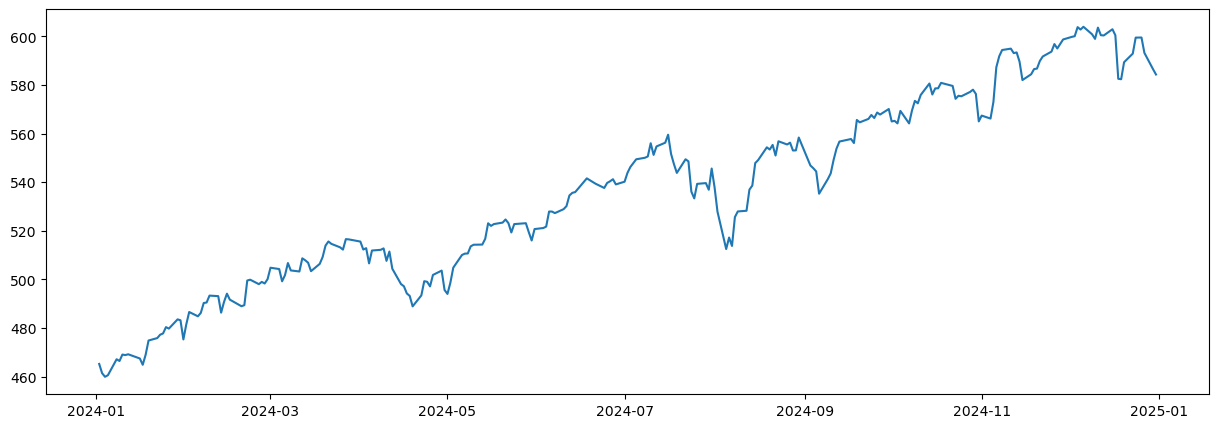

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(sp500['Close'])

In [19]:
data = pd.DataFrame(sp500)
data

,Open,High,Low,Close,Volume,50ma,200ma,return,volatility,corr252,corr50
Date,,,,,,,,,,,
2024-01-02 00:00:00-05:00,464.782040,466.268455,463.138122,465.264374,123623700,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03 00:00:00-05:00,463.079049,463.827183,460.854384,461.464691,103585900,NaN,NaN,-0.008167,NaN,NaN,NaN
2024-01-04 00:00:00-05:00,460.982292,463.600730,459.751824,459.978241,84232200,NaN,NaN,-0.003221,NaN,NaN,NaN
2024-01-05 00:00:00-05:00,460.184973,463.088888,459.141539,460.608276,86060800,NaN,NaN,0.001370,NaN,NaN,NaN
2024-01-08 00:00:00-05:00,461.110298,467.331549,460.982325,467.183899,74879100,NaN,NaN,0.014276,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24 00:00:00-05:00,594.272307,599.536501,593.684050,599.496582,33160100,597.773557,588.349675,0.011115,0.057172,0.101339,0.101339
2024-12-26 00:00:00-05:00,597.701991,600.673034,596.286267,599.536499,41219100,597.908392,588.818362,0.000067,0.056525,0.142652,0.142652
2024-12-27 00:00:00-05:00,595.747844,595.987176,588.988210,593.225464,64969300,597.818100,589.110747,-0.010527,0.057528,0.081530,0.081530


In [33]:
rsi = data.ta.rsi(close='Close', length=14, append=True)
rsi

Date
2024-01-02 00:00:00-05:00          NaN
2024-01-03 00:00:00-05:00          NaN
2024-01-04 00:00:00-05:00          NaN
2024-01-05 00:00:00-05:00          NaN
2024-01-08 00:00:00-05:00          NaN
                               ...    
2024-12-24 00:00:00-05:00    56.013038
2024-12-26 00:00:00-05:00    56.048283
2024-12-27 00:00:00-05:00    49.319625
2024-12-30 00:00:00-05:00    43.312946
2024-12-31 00:00:00-05:00    41.593608
Name: RSI_14, Length: 252, dtype: float64

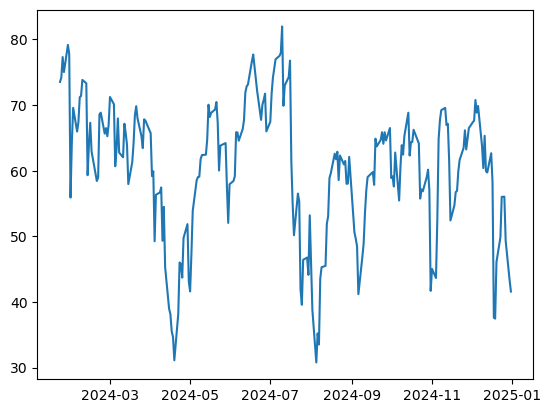

In [55]:
plt.plot(rsi)


In [45]:
indicators = data.ta.rsi(close='Close', length=14, append=True, signal_indicators=True, xa=70, xb=40)


,RSI_14,RSI_14_A_70,RSI_14_B_40
Date,,,
2024-01-02 00:00:00-05:00,NaN,0,0
2024-01-03 00:00:00-05:00,NaN,0,0
2024-01-04 00:00:00-05:00,NaN,0,0
2024-01-05 00:00:00-05:00,NaN,0,0
2024-01-08 00:00:00-05:00,NaN,0,0
...,...,...,...
2024-12-24 00:00:00-05:00,56.013038,0,0
2024-12-26 00:00:00-05:00,56.048283,0,0
2024-12-27 00:00:00-05:00,49.319625,0,0


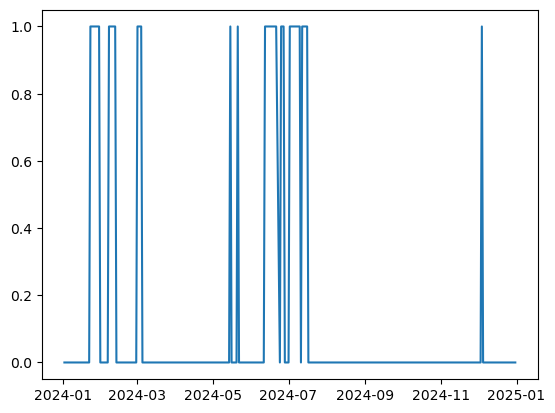

In [47]:
plt.plot(indicators['RSI_14_A_70'])

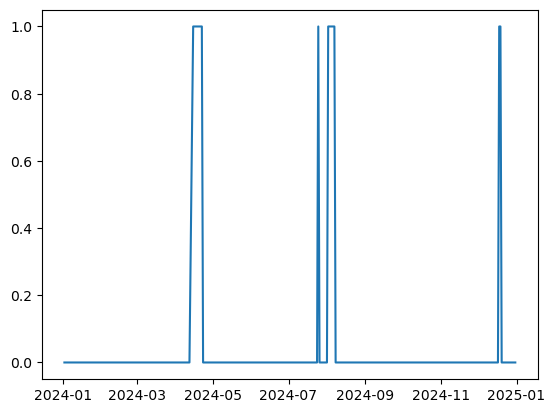

In [49]:
plt.plot(indicators['RSI_14_B_40'])

In [120]:
# Import necessary libraries
from plotly.subplots import make_subplots
import plotly.graph_objects as go
# Create Figure
fig = make_subplots(rows=2, cols=1, shared_xaxes=False, row_width=[0.05, 0.95])
# Inspect Result
print(fig)

Figure({
    'data': [],
    'layout': {'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0]},
               'xaxis2': {'anchor': 'y2', 'domain': [0.0, 1.0]},
               'yaxis': {'anchor': 'x', 'domain': [0.1925, 1.0]},
               'yaxis2': {'anchor': 'x2', 'domain': [0.0, 0.0425]}}
})


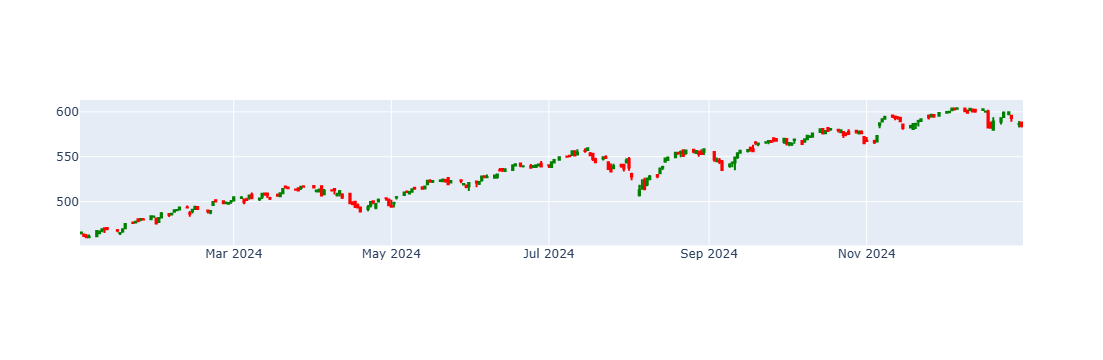

In [122]:
# Create Candlestick chart for price data
fig.add_trace(go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close'],
    increasing_line_color='green',
    decreasing_line_color='red',
    showlegend=False
))
fig.update_layout(xaxis_rangeslider_visible=False)